In [1]:
import fastplotlib as fpl
import masknmf
import numpy as np
import os
import torch
from typing import *

from one.api import ONE
one = ONE()
assert not one.offline, 'ONE must be connect to Alyx for searching imaging sessions'

import pathlib
from pathlib import Path
%load_ext autoreload

No windowing system present. Using surfaceless platform
No config found!
No config found!
Max vertex attribute stride unknown. Assuming it is 2048
Max vertex attribute stride unknown. Assuming it is 2048
Max vertex attribute stride unknown. Assuming it is 2048


Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA TITAN RTX,DiscreteGPU,Vulkan,555.42.02
❗ limited,"llvmpipe (LLVM 12.0.0, 256 bits)",CPU,Vulkan,Mesa 21.2.6 (LLVM 12.0.0)
❌,NVIDIA TITAN RTX/PCIe/SSE2,Unknown,OpenGL,3.3.0 NVIDIA 555.42.02


Max vertex attribute stride unknown. Assuming it is 2048
Max vertex attribute stride unknown. Assuming it is 2048


In [ ]:
#VERIFY VIA THE VIDEOANALYSISWHITEPAPER


In [10]:

class MotionBinDataset:
    """Load a suite2p data.bin imaging registration file."""

    def __init__(self, 
                 data_path: Union[str, pathlib.Path],
                 metadata_path: Union[str, pathlib.Path]):
        """
        Load a suite2p data.bin imaging registration file.

        Parameters
        ----------
        data_path (str, pathlib.Path): The session path containing preprocessed data.
        metadata_path (str, pathlib.Path): The metadata_path to load. 
        """
        self.bin_path = Path(data_path)
        self.ops_path = Path(metadata_path)
        self._dtype = np.int16
        self._shape = self._compute_shape()
        self.data = np.memmap(self.bin_path, mode='r', dtype=self.dtype, shape=self.shape)

    @property
    def dtype(self) -> np.dtype:
        return self._dtype

    @property
    def shape(self):
        """
        This property should return the shape of the dataset, in the form: (d1, d2, T) where d1
        and d2 are the field of view dimensions and T is the number of frames.

        Returns
        -------
        (int, int, int)
            The number of y pixels, number of x pixels, number of frames.
        """
        return self._shape

    @property
    def ndim(self):
        return len(self.shape)

    def _compute_shape(self):
        """
        Loads the suite2p ops file to retrieve the dimensions of the data.bin file.

        Returns
        -------
        (int, int, int)
            number of frames, number of y pixels, number of x pixels.
        """
        ops_file = self.ops_path
        if ops_file.exists():
            ops = np.load(ops_file, allow_pickle=True).item()
        return ops['nframes'], ops['Ly'], ops['Lx']

    def __getitem__(self, item: Union[int, list, np.ndarray, Tuple[Union[int, np.ndarray, slice, range]]]):
        return self.data[item].copy()

    

In [3]:
parent_folder = "/media/app2139/SanDisk_1/IBL/SP044_20230627_001/plane9/"
bin_path = os.path.join(parent_folder, "data.bin")
ops_path = os.path.join(parent_folder, "ops.npy")
my_data = MotionBinDataset(bin_path, ops_path)[:]
my_data = my_data[:, 5:-5, 5:-5]

In [4]:
results = np.load("../../demixing_results/demixing_results_20250801_100716.npz", allow_pickle = True)['results'].item()

In [4]:
eids = ONE().search(
    subject='SP044', 
    number="001",
    date_range=['2023-06-26', '2023-06-28'],
)
eids

[UUID('97334cc3-059f-4fb9-8413-3fe0288a7144')]

In [5]:
eid_used = eids[0]

In [6]:
one.list_datasets(eids[0])

['_ibl_experiment.description.yaml',
 'alf/FOV_00/_suite2p_ROIData.raw.zip',
 'alf/FOV_00/mpci.ROIActivityDeconvolved.npy',
 'alf/FOV_00/mpci.ROIActivityF.npy',
 'alf/FOV_00/mpci.ROINeuropilActivityF.npy',
 'alf/FOV_00/mpci.badFrames.npy',
 'alf/FOV_00/mpci.mpciFrameQC.npy',
 'alf/FOV_00/mpci.times.npy',
 'alf/FOV_00/mpciFrameQC.names.tsv',
 'alf/FOV_00/mpciMeanImage.brainLocationIds_ccf_2017_estimate.npy',
 'alf/FOV_00/mpciMeanImage.images.npy',
 'alf/FOV_00/mpciMeanImage.mlapdv_estimate.npy',
 'alf/FOV_00/mpciROITypes.names.tsv',
 'alf/FOV_00/mpciROIs.brainLocationIds_ccf_2017_estimate.npy',
 'alf/FOV_00/mpciROIs.cellClassifier.npy',
 'alf/FOV_00/mpciROIs.masks.sparse_npz',
 'alf/FOV_00/mpciROIs.mlapdv_estimate.npy',
 'alf/FOV_00/mpciROIs.mpciROITypes.npy',
 'alf/FOV_00/mpciROIs.neuropilMasks.sparse_npz',
 'alf/FOV_00/mpciROIs.stackPos.npy',
 'alf/FOV_00/mpciROIs.uuids.csv',
 'alf/FOV_00/mpciStack.timeshift.npy',
 'alf/FOV_01/_suite2p_ROIData.raw.zip',
 'alf/FOV_01/mpci.ROIActivityDe

In [7]:
mp_times = one.load_dataset(eids[0], 'mpci.times', collection = 'alf/FOV_00')

# objects = ['mpci', 'mpciROIs', 'mpciROITypes', 'mpciStack']
# ROI_data_00 = one.load_collection(eid, 'alf/FOV_00', object=objects)

In [ ]:
frame_times = mp_times['mpci']['times']
roi_xyz = mp_times['mpciROIs']['stackPos']
timeshift = mp_times['mpciStack']['timeshift']
roi_offsets = timeshift[roi_xyz[:, len(timeshift.shape)]]

In [8]:
mp_times

array([1.008500e+00, 1.154500e+00, 1.301000e+00, ..., 4.161740e+03,
       4.161886e+03, 4.162032e+03], shape=(27170,))

In [ ]:
# Stimulus position is hard to access, but stimulus times (left vs. right vs. locked in center) are available, this is how to access it

In [ ]:
# task_00 is the active, task_01 is the passive (task_00 is what we should look at in general) 

In [39]:
trials = one.load_object(eids[0], 'trials')
trials = trials.to_df()

In [40]:
trials.columns

Index(['quiescencePeriod', 'stimOnTrigger_times', 'stimOff_times',
       'stimOffTrigger_times', 'goCueTrigger_times', 'repNum', 'goCue_times',
       'response_times', 'choice', 'stimOn_times', 'contrastLeft',
       'contrastRight', 'feedback_times', 'feedbackType', 'rewardVolume',
       'probabilityLeft', 'firstMovement_times', 'intervals_0', 'intervals_1'],
      dtype='object')

In [51]:
c_left = trials['contrastLeft']
c_right = trials['contrastRight']
choice = trials['choice']
correct_left = np.logical_and(choice > 0, ~np.isnan(c_left))
correct_right = np.logical_and(choice < 0, ~np.isnan(c_right))
overall_correct = np.logical_or(correct_left, correct_right)
# correct =  or (np.logical_and(choice < 0 and ~np.isnan(c_right)))

In [ ]:
# Stim off gives the clock time when the stimulus is turned off

In [54]:
trials['feedbackType']

0      1.0
1      1.0
2      1.0
3     -1.0
4      1.0
      ... 
418    1.0
419   -1.0
420   -1.0
421   -1.0
422   -1.0
Name: feedbackType, Length: 423, dtype: float64

In [53]:
trials['rewardVolume']

0      1.9
1      1.9
2      1.9
4      1.9
5      1.9
      ... 
401    1.9
402    1.9
404    1.9
409    1.9
418    1.9
Name: rewardVolume, Length: 264, dtype: float64

In [47]:
trials['stimOn_times'] # This is when the stim is turned on

0        39.6330
1        45.5620
2        49.3640
3        52.4660
4        74.4330
         ...    
418    2908.9890
419    2912.0725
420    2926.9370
421    2934.6230
422    2952.3050
Name: stimOn_times, Length: 423, dtype: float64

In [48]:
trials['feedback_times']

0        42.7555
1        46.6815
2        49.8685
3        70.6210
4        86.1935
         ...    
418    2909.3905
419    2923.1400
420    2930.8255
421    2947.5715
422    2958.2065
Name: feedback_times, Length: 423, dtype: float64

In [41]:
trials['contrastLeft']

0      NaN
1      NaN
2      NaN
3      NaN
4      0.0
      ... 
418    1.0
419    NaN
420    NaN
421    NaN
422    NaN
Name: contrastLeft, Length: 423, dtype: float64

In [44]:
trials['contrastRight']

0      0.0625
1      0.0625
2      0.0625
3      0.2500
4         NaN
        ...  
418       NaN
419    1.0000
420    0.0625
421    0.0625
422    1.0000
Name: contrastRight, Length: 423, dtype: float64

In [ ]:
# Want to filter 1.0 

In [20]:
one.list_datasets(eids[0], collection='alf')

['alf/_ibl_leftCamera.dlc.pqt',
 'alf/_ibl_leftCamera.features.pqt',
 'alf/_ibl_leftCamera.times.npy',
 'alf/_ibl_rightCamera.dlc.pqt',
 'alf/_ibl_rightCamera.features.pqt',
 'alf/_ibl_rightCamera.times.npy',
 'alf/leftCamera.ROIMotionEnergy.npy',
 'alf/leftROIMotionEnergy.position.npy',
 'alf/licks.times.npy',
 'alf/rightCamera.ROIMotionEnergy.npy',
 'alf/rightROIMotionEnergy.position.npy']

In [21]:
loaded_files = one.load_object(eid_used, 'leftCamera', collection='alf')

(S3) /media/app2139/SanDisk_1/IBL_Alyx/cortexlab/Subjects/SP044/2023-06-27/001/alf/_ibl_leftCamera.times.npy: 100%|██████████████████████████████████████████████████████████████████████████████████████| 5.12M/5.12M [00:00<00:00, 18.2MB/s]
(S3) /media/app2139/SanDisk_1/IBL_Alyx/cortexlab/Subjects/SP044/2023-06-27/001/alf/leftCamera.ROIMotionEnergy.npy: 100%|█████████████████████████████████████████████████████████████████████████████████| 5.12M/5.12M [00:00<00:00, 17.5MB/s]
(S3) /media/app2139/SanDisk_1/IBL_Alyx/cortexlab/Subjects/SP044/2023-06-27/001/alf/_ibl_leftCamera.dlc.pqt: 100%|████████████████████████████████████████████████████████████████████████████████████████| 89.3M/89.3M [00:01<00:00, 63.4MB/s]
(S3) /media/app2139/SanDisk_1/IBL_Alyx/cortexlab/Subjects/SP044/2023-06-27/001/alf/_ibl_leftCamera.features.pqt: 100%|███████████████████████████████████████████████████████████████████████████████████| 9.87M/9.87M [00:00<00:00, 15.6MB/s]


In [9]:
# Load the left camera raw video

#raw_video_data/_iblrig_leftCamera.raw.mp4'
raw_vid = one.load_object(eid_used, 'leftCamera', collection='raw_video_data', download_only=True)

(S3) /media/app2139/SanDisk_1/IBL_Alyx/cortexlab/Subjects/SP044/2023-06-27/001/raw_video_data/_iblrig_leftCamera.raw.mp4: 100%|████████████████████████████████████████| 17.0G/17.0G [02:25<00:00, 117MB/s]
(S3) /media/app2139/SanDisk_1/IBL_Alyx/cortexlab/Subjects/SP044/2023-06-27/001/raw_video_data/_iblrig_leftCamera.frameData.bin: 100%|█████████████████████████████████| 20.5M/20.5M [00:00<00:00, 34.8MB/s]


In [25]:
import pandas as pd

In [35]:
one.get_details(eid_used)

{'subject': 'SP044',
 'start_time': '2023-06-27T14:04:29.532000',
 'number': 1,
 'lab': 'cortexlab',
 'projects': 'ibl_mesoscope_active',
 'url': 'https://alyx.internationalbrainlab.org/sessions/97334cc3-059f-4fb9-8413-3fe0288a7144',
 'task_protocol': '_iblrig_tasks_trainingChoiceWorld7.0.5/_iblrig_tasks_passiveChoiceWorldIndependent7.0.5',
 'date': datetime.date(2023, 6, 27),
 'local_path': PosixALFPath('/media/app2139/SanDisk_1/IBL_Alyx/cortexlab/Subjects/SP044/2023-06-27/001')}

In [26]:
dlc_df = loaded_files.dlc

In [34]:
len(loaded_files.times)

639919

In [29]:
dlc_df['nose_tip_x']

0         81.561935
1         82.277962
2         82.504532
3         82.504532
4         82.504532
            ...    
639914    85.342335
639915    83.817516
639916    83.258797
639917    82.238148
639918    80.995178
Name: nose_tip_x, Length: 639919, dtype: float64

In [10]:
# Find mesoscope imaging sessions

# eids = ONE().search(
#     subject='SP044', 
#     date_range=['2023-06-26', '2023-06-28'],
#     number="001"
# )

eid_used = eids[0]
collection = "alf/FOV_09"
one.list_datasets(eid_used, collection=collection + "*")

neuropil_mask = one.load_dataset(eid_used, 'mpciROIs.neuropilMasks.sparse_npz', collection=collection)
signal_mask = one.load_dataset(eid_used, 'mpciROIs.masks.sparse_npz', collection=collection)

neuropil_timeseries = one.load_dataset(eid_used, 'mpci.ROINeuropilActivityF.npy', collection=collection)
signal_timeseries = one.load_dataset(eid_used, 'mpci.ROIActivityF.npy', collection=collection)


local file size mismatch on dataset: cortexlab/Subjects/SP044/2023-06-27/001/alf/FOV_09/mpci.ROINeuropilActivityF.npy
(S3) /data/home/app2139/Downloads/ONE/alyx.internationalbrainlab.org/cortexlab/Subjects/SP044/2023-06-27/001/alf/FOV_09/mpci.ROINeuropilActivityF.npy: 100%|█████████████████████████████████████████████| 89.6M/89.6M [00:02<00:00, 41.3MB/s]
local file size mismatch on dataset: cortexlab/Subjects/SP044/2023-06-27/001/alf/FOV_09/mpci.ROIActivityF.npy
(S3) /data/home/app2139/Downloads/ONE/alyx.internationalbrainlab.org/cortexlab/Subjects/SP044/2023-06-27/001/alf/FOV_09/mpci.ROIActivityF.npy: 100%|█████████████████████████████████████████████████████| 89.6M/89.6M [00:01<00:00, 52.4MB/s]


In [11]:
neuropil_mask_dense = neuropil_mask.todense().transpose(1, 2, 0).astype(np.float32) #H, W, Frames
signal_mask_dense = signal_mask.todense().transpose(1,2,0).astype(np.float32) #H, W, Frames

neuropil_mask_dense = neuropil_mask_dense[5:-5, 5:-5, :].astype(np.float32) #Cropping
signal_mask_dense = signal_mask_dense[5:-5, 5:-5, :].astype(np.float32) # Cropping
fov_shape = signal_mask_dense.shape[0], signal_mask_dense.shape[1]

neuropil_mask_dense = neuropil_mask_dense.reshape((-1, neuropil_mask_dense.shape[2]))
signal_mask_dense = signal_mask_dense.reshape((-1, signal_mask_dense.shape[2]))

signal_mask_torch =  masknmf.demixing.demixing_utils.ndarray_to_torch_sparse_coo(signal_mask_dense).float()
neuropil_mask_torch =  masknmf.demixing.demixing_utils.ndarray_to_torch_sparse_coo(neuropil_mask_dense).float()

signal_timeseries_torch = torch.from_numpy(signal_timeseries).float()
neuropil_timeseries_torch = torch.from_numpy(neuropil_timeseries).float()

suite2p_ac = masknmf.ACArray(fov_shape,
                             "C",
                             signal_mask_torch.to('cuda'),
                             signal_timeseries_torch.to('cuda'))

suite2p_neuropil = masknmf.ACArray(fov_shape,
                                 "C",
                                 neuropil_mask_torch.to('cuda'),
                                 neuropil_timeseries_torch.to('cuda'))

suite2p_colorful_signal = masknmf.ColorfulACArray(fov_shape,
                                                  "C",
                                                  signal_mask_torch.to('cuda'),
                                                  signal_timeseries_torch.to('cuda'))
                                                  

In [12]:
print(suite2p_ac.shape)
print(results.pmd_array.shape)

(13585, 502, 502)
(13585, 502, 502)


In [15]:
my_mean = np.mean(my_data, axis = 0, keepdims = True)
mean_zero = my_data - my_mean

In [13]:
results.to('cuda')

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
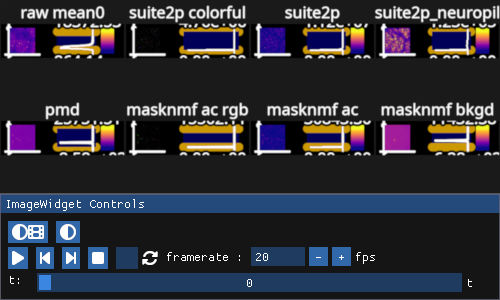

Error during handling pointer_up event: IM_ASSERT( mouse_button >= 0 … (11)
Error during handling pointer_up event: IM_ASSERT( mouse_button >= 0 … (12)
Error during handling pointer_up event: IM_ASSERT( mouse_button >= 0 … (13)
Error during handling pointer_up event: IM_ASSERT( mouse_button >= 0 … (14)


In [17]:
iw = fpl.ImageWidget(data = [my_mean.squeeze(),
                             suite2p_colorful_signal,
                             suite2p_ac,
                             suite2p_neuropil,
                             results.pmd_array,
                            results.colorful_ac_array,
                            results.ac_array,
                            results.fluctuating_background_array],
                     names = ['raw mean0',
                              'suite2p colorful',
                             'suite2p',
                              'suite2p_neuropil',
                              'pmd',
                              'masknmf ac rgb',
                             'masknmf ac',
                             'masknmf bkgd'],
                    figure_shape = (2, 4),
                    rgb=[False,True,False,False,False,True,False,False])
iw.show()

(502, 502)

RFBOutputContext()

Max vertex attribute stride unknown. Assuming it is 2048
/data/home/app2139/fastplotlib/fastplotlib/tools/_histogram_lut.py:200: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, edges = np.histogram(data_ss, bins=self._nbins)
/data/home/app2139/fastplotlib/fastplotlib/graphics/features/_base.py:18: UserWarning: casting float64 array to float32
  warn(f"casting {array.dtype} array to float32")


JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
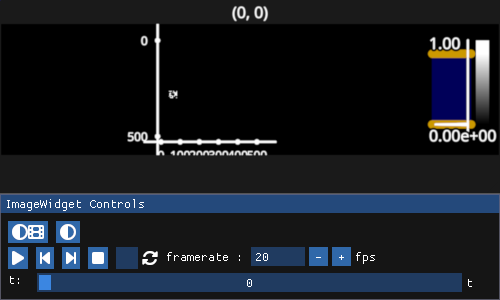

In [23]:
iw = fpl.ImageWidget(data = [neuropil_mask_dense])
iw.cmap = "gray"
iw.show()

In [19]:
type(neuropil_mask)

sparse.numba_backend._compressed.compressed.GCXS

In [4]:
"/media/app2139/SanDisk_1/IBL/SP044_20230627_001/

[UUID('b544646b-d945-42c7-a9d3-7112d508e2d2'),
 UUID('8be43e01-31b7-4096-8613-491bf35f5c0f'),
 UUID('53633b3e-332a-4c02-9e7e-af6475cc2b41'),
 UUID('475d9a25-022c-4d62-8cb9-a430ff5db229'),
 UUID('b949c9c8-97ea-4a94-b048-93d9530c6b0b'),
 UUID('e75d26d3-d474-4351-8b42-361b91f50990'),
 UUID('600ce551-a3ab-4f41-9c79-a2e781abe2a7'),
 UUID('c0ec7310-3d78-4f62-be57-acd46de7c610'),
 UUID('263d3689-583b-40a7-a763-6e457faa54ac'),
 UUID('582bd98f-399e-4e02-995b-3ab81b79b86b'),
 UUID('ef5f3156-4560-4f78-9f61-7953802711ba'),
 UUID('bd3a5a95-99c8-4274-845f-eba4ecc05908'),
 UUID('3e4dbec4-71f7-476c-8bbf-e8c526ee50c2'),
 UUID('2514fe00-c408-48a1-927b-3462b8e682bc'),
 UUID('a56482be-0a3b-46cb-86cf-50c2020fd7f4'),
 UUID('cf8d521d-b25f-4999-bf40-16ad9ab15578'),
 UUID('c45aeaa1-db5a-46ec-bf31-0d524b43c963'),
 UUID('4e9e0ddc-9cc5-422a-a3a5-134d9cb6d08e'),
 UUID('a3690e0c-496e-4be1-bab1-6adff895ca5c'),
 UUID('76476a80-58bb-47a3-b214-21d67d70b56e'),
 UUID('ffa0d2ae-a898-40aa-bf26-d7a92f3f0f8e'),
 UUID('fa6da9